# JWST NIRSpec IFU Spectra Extraction

In [1]:
import numpy as np
from astropy.io import fits
from astropy import wcs
from scipy.ndimage import binary_dilation
from scipy.signal import savgol_filter
import sep
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import os

In [2]:
# Set up parameters
grating = 'G395H'
bkg_sub_file = 'd:/Fudan_University/Research/JWST/NIRSpec_IFU/COS-87259_BGSUB_g395h-f290lp_s3d.fits'
output_dir = 'd:/Fudan_University/Research/JWST/extracted_spectra'
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Load background-subtracted IFU spectra
s3d = fits.open(bkg_sub_file)
hdr = s3d['sci'].header
f3d = s3d['sci'].data
e3d = s3d['err'].data

# Wavelength array (unit: micron)
wl0, dwl, wl_len = hdr['CRVAL3'], hdr['CDELT3'], hdr['NAXIS3']
wl = wl0 + np.arange(wl_len) * dwl

# Detection wavelength range
if grating == 'prism':
    wl_det = (wl > 0.95) & (wl < 5.29)
elif grating == 'G395H':
    wl_det = (wl > 2.87) & (wl < 5.27)
    
# Coadd 2D map using inverse variance weighted stacking
ivw_stack = np.nanmean(f3d[wl_det] / e3d[wl_det]**2, axis=0) / np.nanmean(1. / e3d[wl_det]**2, axis=0)

# Mask bad pixels
nan_mask = np.isnan(ivw_stack)

C:\Users\zhigu\AppData\Local\Temp\ipykernel_36336\2051826563.py:18: RuntimeWarning: Mean of empty slice
  ivw_stack = np.nanmean(f3d[wl_det] / e3d[wl_det]**2, axis=0) / np.nanmean(1. / e3d[wl_det]**2, axis=0)


In [4]:
# Clump information (Center, West, North, South, Southeast)
clump_ids = ['Center', 'West', 'North', 'South', 'Southeast']
x = np.array([27.2994, 27.2994, 27.5317, 26.9051, 19.7599]) # center X
y = np.array([24.2436, 24.2436, 28.4938, 15.3950, 20.7517]) # center Y
a = np.array([2.0362, 2.0362, 1.4309, 3.2745, 2.0370]) # semi-major axis
b = np.array([1.4896, 1.4896, 1.3812, 1.0209, 1.0339]) # semi-minor axis
r = np.array([2.6471, 2.6471, 3.2883, 2.5689, 2.2962]) # radius
theta = np.array([-0.1644, -0.1644, -0.0619, -0.3366, 0.9059]) # inclination angle

## Visualizing Extracted Clumps with Elliptical Apertures

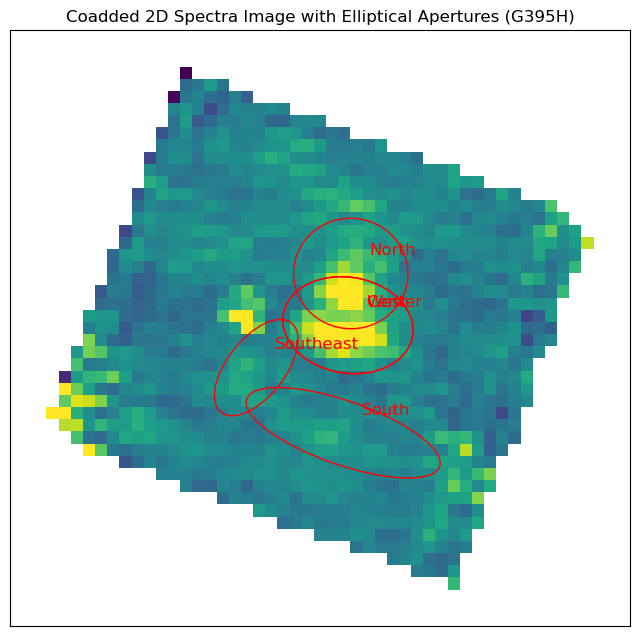

In [5]:
# Plot the rest-frame optical wavelength coadded 2D spectra image with elliptical apertures
plt.figure(figsize=(8, 8))

# Background subtracted mask
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)
stack_bkg_sub = ivw_stack - bkg
stack_bkg_sub[nan_mask] = np.nan

m, s = np.nanmean(stack_bkg_sub), np.nanstd(stack_bkg_sub)
plt.imshow(stack_bkg_sub, vmin=m-3*s, vmax=m+3*s, origin='lower')

# Plot the elliptical aperture for each clump
for n, clump_id in enumerate(clump_ids):
    e = Ellipse(xy=(x[n], y[n]), width=2.*a[n]*r[n], height=2.*b[n]*r[n], 
                angle=theta[n]*180./np.pi, facecolor='none', edgecolor='r')
    plt.gca().add_patch(e)
    # Add text label slightly offset from the center
    plt.text(x[n] + 1.5, y[n] + 1.5, clump_id, color='red', fontsize=12)

plt.xticks([])
plt.yticks([])
plt.title(f"Coadded 2D Spectra Image with Elliptical Apertures ({grating})")
plt.show()

## Extracting the 1D Spectra

In [ ]:
# Extract 1D spectra for each clump
fnu_0 = hdr['PIXAR_SR']
extracted_data = {}

for n, clump_id in enumerate(clump_ids):
    print(f"Extracting {clump_id}...")
    flux_mask = nan_mask.copy()
    
    # Mask pixels from other clumps (specific to Center, West, North to avoid overlap)
    tmp_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)
    
    if clump_id == 'Center':
        tmp_stack[27:, :] = np.nan
        tmp_stack[:, 29:] = np.nan
        flux_mask = np.isnan(tmp_stack) | nan_mask
    elif clump_id == 'West':
        tmp_stack[27:, :] = np.nan
        tmp_stack[:, :29] = np.nan
        flux_mask = np.isnan(tmp_stack) | nan_mask
    elif clump_id == 'North':
        tmp_stack[:27, :] = np.nan
        flux_mask = np.isnan(tmp_stack) | nan_mask

    f1d, e1d = np.zeros_like(wl), np.zeros_like(wl)
    
    for i in range(wl_len):
        f2d, e2d = f3d[i], e3d[i]
        
        # byte order fix for sep
        f2d = f2d.astype(f2d.dtype.newbyteorder('='))
        e2d = e2d.astype(e2d.dtype.newbyteorder('='))
        
        # Extracted flux
        aper_flux, _, _ = sep.sum_ellipse(f2d, [x[n]], [y[n]], [a[n]], [b[n]], [theta[n]], [r[n]], mask=flux_mask)
        f1d[i] = aper_flux[0] * fnu_0
        
        # Extracted error
        aper_err, _, _ = sep.sum_ellipse(e2d**2, [x[n]], [y[n]], [a[n]], [b[n]], [theta[n]], [r[n]], mask=flux_mask)
        e1d[i] = np.sqrt(aper_err[0]) * fnu_0

    # Convert to erg/s/cm^2/Angstrom
    f1d_cgs = f1d * 1e-17 * 3e18 / (wl * 1e4)**2
    e1d_cgs = e1d * 1e-17 * 3e18 / (wl * 1e4)**2
    
    extracted_data[clump_id] = {
        'wl': wl,
        'f1d': f1d_cgs,
        'e1d': e1d_cgs
    }

    # Save to file
    output_file = os.path.join(output_dir, f"{clump_id}_{grating}_spectrum.txt")
    np.savetxt(output_file, np.column_stack((wl, f1d_cgs, e1d_cgs)), header="Wavelength(um) Flux(erg/s/cm2/A) Flux_Err", fmt='%.6e')
    print(f"  Saved to {output_file}")
print("Extraction complete.")

Extracting Center...


C:\Users\zhigu\AppData\Local\Temp\ipykernel_36336\1562627617.py:10: RuntimeWarning: Mean of empty slice
  tmp_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)


  Saved to d:/Fudan_University/Research/JWST/extracted_spectra\Center_G395H_spectrum.txt
Extracting West...
  Saved to d:/Fudan_University/Research/JWST/extracted_spectra\West_G395H_spectrum.txt
Extracting North...
  Saved to d:/Fudan_University/Research/JWST/extracted_spectra\North_G395H_spectrum.txt
Extracting South...
  Saved to d:/Fudan_University/Research/JWST/extracted_spectra\South_G395H_spectrum.txt
Extracting Southeast...
  Saved to d:/Fudan_University/Research/JWST/extracted_spectra\Southeast_G395H_spectrum.txt
Extraction complete.


## Ploting the 1D spectra [plot_spectra.py]

Plot saved.


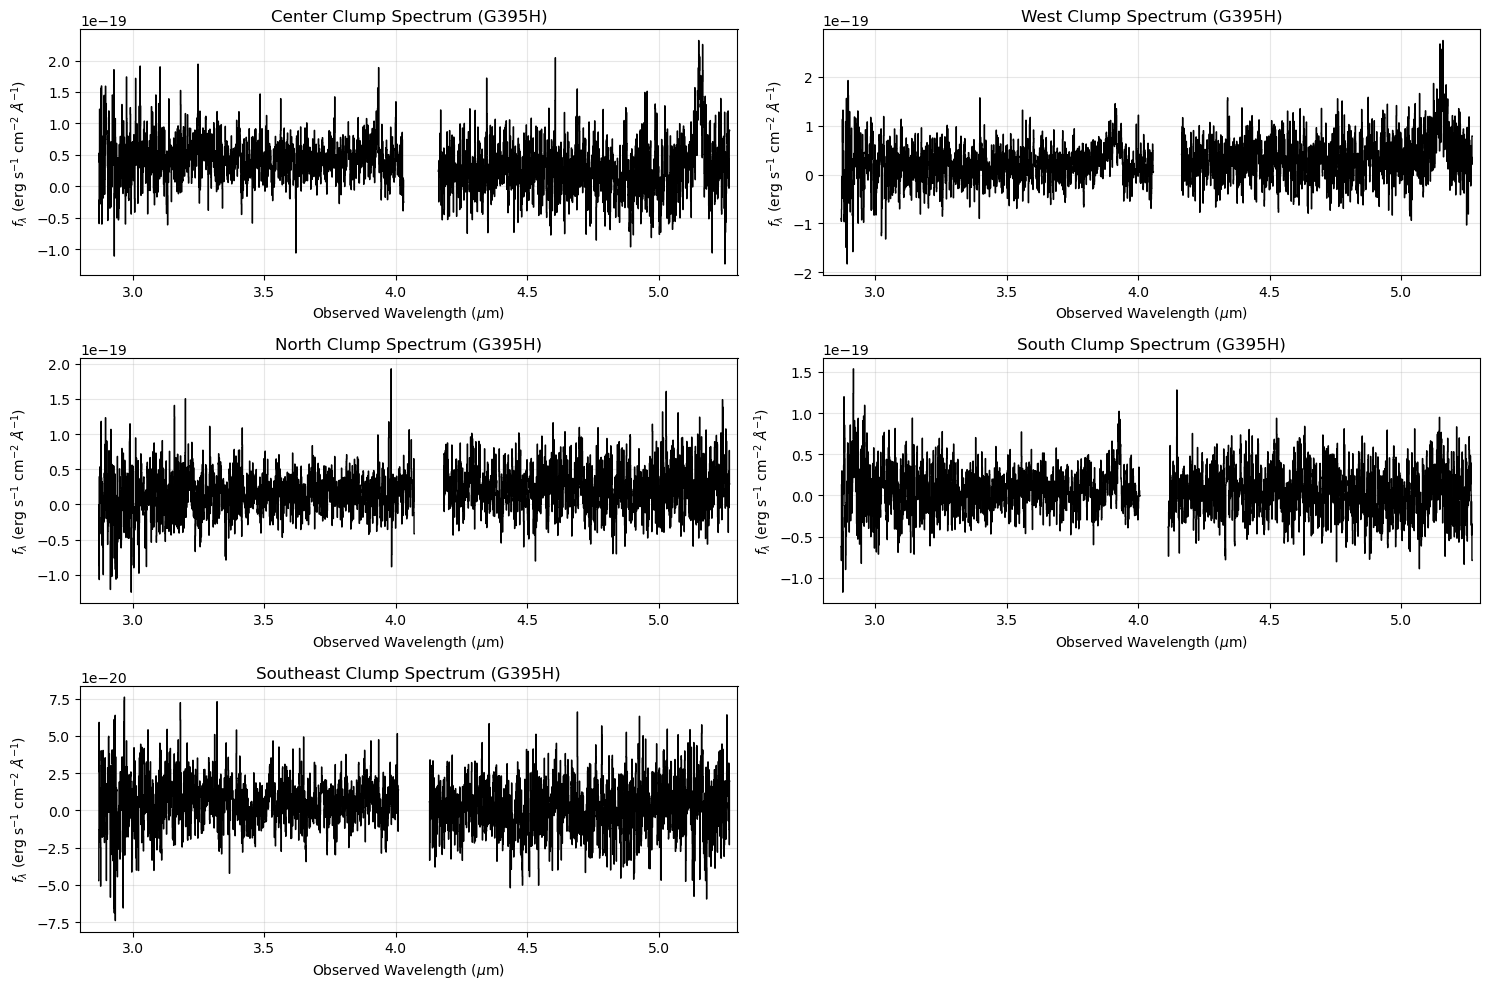

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

spectra_dir = 'd:/Fudan_University/Research/JWST/extracted_spectra'
clumps = ['Center', 'West', 'North', 'South', 'Southeast']
grating = 'G395H'

plt.figure(figsize=(15, 10))

for i, clump in enumerate(clumps):
    file_path = os.path.join(spectra_dir, f'{clump}_{grating}_spectrum.txt')
    
    if os.path.exists(file_path):
        data = np.loadtxt(file_path, skiprows=1)
        wl = data[:, 0]
        flux = data[:, 1]
        
        plt.subplot(3, 2, i + 1)
        plt.plot(wl, flux, 'k-', ds='steps-mid', lw=1)
        plt.title(f'{clump} Clump Spectrum ({grating})')
        plt.xlabel('Observed Wavelength ($\mu$m)')
        plt.ylabel('$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
        plt.xlim(2.8, 5.3)
        plt.grid(True, alpha=0.3)
    else:
        print(f"Warning: {file_path} not found.")

plt.tight_layout()
plt.savefig(os.path.join(spectra_dir, f'all_clumps_{grating}.png'), dpi=300)
print("Plot saved.")